# Machine Learning Lab - Task 02
## Supervised Learning: Regression and Classification Pipelines

This laboratory assignment covers two core supervised workflows:
1. **Linear Regression**: Continuous estimation of a student's final examination score based on study hours and prior score.
2. **Logistic Regression**: Binary classification of student pass/fail status based on behavioral features.
3. **Inference Pipeline**: Model inference on unseen student candidate profiles.

### 1. Import Libraries and Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report
)

---
## Part 1: Linear Regression (Final Score Estimation)

We synthesize a dataset of $n = 100$ records where `final_score` is a linear combination of study time and prior academic marks, perturbed by Gaussian noise $\epsilon \sim \mathcal{N}(0, 5)$:

$$\text{final\_score} = 20 + 4(\text{study\_hours}) + 0.5(\text{previous\_score}) + \epsilon$$

Values are bounded between $[0, 100]$ using clipping.

In [3]:
np.random.seed(42)
n = 100

# Generate input features
study_hours = np.random.randint(1, 11, n)
previous_score = np.random.randint(40, 91, n)

# Generate continuous ground truth
final_score = (
    20
    + 4 * study_hours
    + 0.5 * previous_score
    + np.random.normal(0, 5, n)
)
final_score = np.clip(final_score, 0, 100)

# Construct DataFrame
df_reg = pd.DataFrame({
    "study_hours": study_hours,
    "previous_score": previous_score,
    "final_score": final_score
})

print("Dataset shape:", df_reg.shape)
print("\nFirst 5 rows:")
display(df_reg.head())

Dataset shape: (100, 3)

First 5 rows:


,study_hours,previous_score,final_score
0,7,51,70.204088
1,4,73,72.519687
2,8,72,90.388770
3,5,87,82.204857
4,7,62,76.126454


### Train-Test Split and Regressor Training
We partition the regression dataset into an 80/20 train-test split (`test_size=0.20`, `random_state=42`).

In [4]:
X = df_reg[["study_hours", "previous_score"]]
y = df_reg["final_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

model_reg = LinearRegression()
model_reg.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

X shape: (100, 2)
y shape: (100,)
Training records: 80
Testing records: 20
Linear Regression model trained successfully.


### Regression Predictions and Residual Diagnostics
Compute predictions for the test split and evaluate residuals.

In [5]:
y_pred = model_reg.predict(X_test)
print("Predicted scores (First 10):")
print(y_pred[:10])

reg_results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred.round(2)
})
display(reg_results.head(10))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

Predicted scores (First 10):
[53.16156809 68.96945507 92.25496956 78.1975501  94.89479697 68.53607603
 88.30935457 88.73990839 68.09704653 75.56902359]


,Actual Score,Predicted Score
0,48.435173,53.16
1,63.727514,68.97
2,84.967974,92.25
3,83.585354,78.20
4,97.088204,94.89
5,65.970666,68.54
6,86.545722,88.31
7,93.727856,88.74
8,62.623319,68.10
9,70.204088,75.57



Mean Absolute Error (MAE): 4.04
Mean Squared Error (MSE): 18.36


### Regression Visualization
Scatter plot comparing ground truth labels against model estimations.

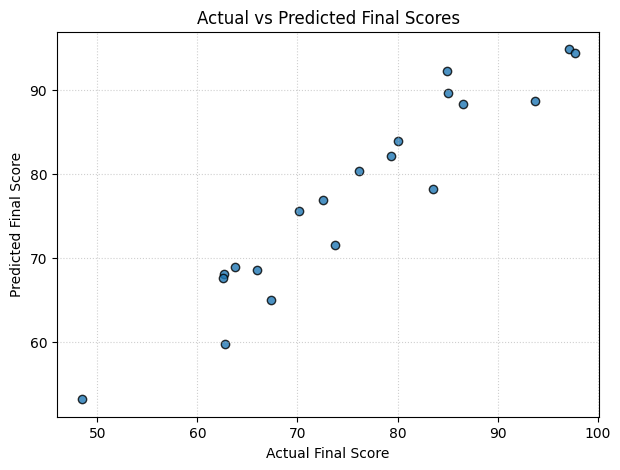

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color="#1f77b4", edgecolors="k", alpha=0.8)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Scores")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

---
## Part 2: Logistic Regression (Student Pass/Fail Classification)

We synthesize $n = 200$ student records across three features: `study_hours`, `attendance`, and `previous_score`.
A student receives a passing label (`1`) if at least 2 of the following conditions are satisfied:
- `study_hours >= 5`
- `attendance >= 70`
- `previous_score >= 60`

In [7]:
np.random.seed(42)
n = 200

# Generate features
study_hours = np.random.randint(1, 11, n)
attendance = np.random.randint(50, 101, n)
previous_score = np.random.randint(40, 91, n)

# Threshold rule (pass if >= 2 conditions met)
score = (
    (study_hours >= 5).astype(int)
    + (attendance >= 70).astype(int)
    + (previous_score >= 60).astype(int)
)
passed = (score >= 2).astype(int)

# Construct DataFrame
df_cls = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "previous_score": previous_score,
    "passed": passed
})

print("Dataset shape:", df_cls.shape)
print("\nFirst 5 rows:")
display(df_cls.head())
print("\nClass distribution:")
print(df_cls["passed"].value_counts())

Dataset shape: (200, 4)

First 5 rows:


,study_hours,attendance,previous_score,passed
0,7,71,82,1
1,4,60,76,0
2,8,97,72,1
3,5,65,47,0
4,7,82,83,1



Class distribution:
passed
1    143
0     57
Name: count, dtype: int64


### Train-Test Split and Classifier Fitting
Split features into 80% training ($n=160$) and 20% testing ($n=40$) sets.

In [8]:
X = df_cls[["study_hours", "attendance", "previous_score"]]
y = df_cls["passed"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

model_cls = LogisticRegression()
model_cls.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

X shape: (200, 3)
y shape: (200,)
Training records: 160
Testing records: 40
Logistic Regression model trained successfully.


### Classification Evaluation & Metrics

In [9]:
y_pred = model_cls.predict(X_test)
print("Predictions (First 20):")
print(y_pred[:20])

classification_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
display(classification_results.head(15))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 2))
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)

Predictions (First 20):
[1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1]


,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,0
6,1,1
7,1,1
8,1,1
9,1,1


Accuracy: 0.95
Accuracy percentage: 95.0 %

Confusion Matrix:
[[ 8  1]
 [ 1 30]]
True Negative: 8
False Positive: 1
False Negative: 1
True Positive: 30


### Confusion Matrix Visualization & Classification Report

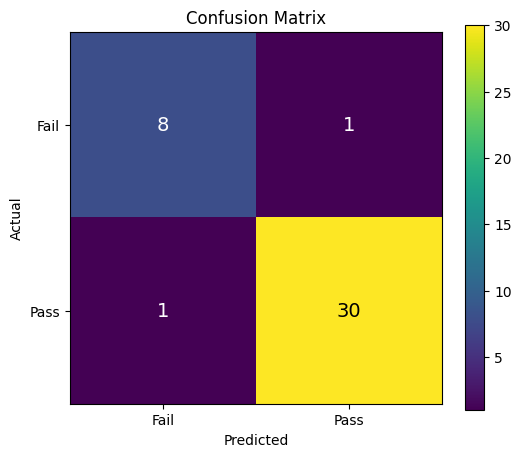


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.97      0.97      0.97        31

    accuracy                           0.95        40
   macro avg       0.93      0.93      0.93        40
weighted avg       0.95      0.95      0.95        40



In [10]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="viridis")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm[i, j] < 20 else "black"
        )

plt.colorbar()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

---
## Part 3: Task 3 - New Student Predictions
Using the trained logistic classifier to predict outcomes on unseen records.

In [11]:
new_students = pd.DataFrame({
    "study_hours": [2, 6, 9],
    "attendance": [55, 75, 95],
    "previous_score": [45, 65, 85]
})

print("New Student Profiles:")
display(new_students)

new_predictions = model_cls.predict(new_students)
new_probabilities = model_cls.predict_proba(new_students)[:, 1]

new_students["Predicted_Class"] = new_predictions
new_students["Status"] = ["Pass" if p == 1 else "Fail" for p in new_predictions]
new_students["Pass_Probability"] = new_probabilities.round(3)

print("\nEvaluation on Unseen Records:")
display(new_students)

New Student Profiles:


,study_hours,attendance,previous_score
0,2,55,45
1,6,75,65
2,9,95,85



Evaluation on Unseen Records:


,study_hours,attendance,previous_score,Predicted_Class,Status,Pass_Probability
0,2,55,45,0,Fail,0.003
1,6,75,65,1,Pass,0.896
2,9,95,85,1,Pass,1.000
